Print the directory structure

In [2]:
from pathlib import Path

dataset_path = Path("../../data/item_images/raw/recybat24")

for path in dataset_path.iterdir():
    print(path.name)

for split in ["train", "val"]:
    print(f"\n{split}:")
    split_path = dataset_path / split
    
    for item in split_path.iterdir():
        print("   ", item.name)

train
val

train:
    10_1_1_cyl.jpg
    10_1_2_cyl.jpg
    10_1_3_cyl.jpg
    10_1_F_1_po.jpg
    10_1_F_1_pri.jpg
    10_1_F_2_po.jpg
    10_1_F_2_pri.jpg
    10_1_F_3_po.jpg
    10_1_F_3_pri.jpg
    10_2_1_cyl.jpg
    10_2_2_cyl.jpg
    10_2_3_cyl.jpg
    10_2_F_1_po.jpg
    10_2_F_1_pri.jpg
    10_2_F_2_po.jpg
    10_2_F_2_pri.jpg
    10_2_F_3_po.jpg
    10_2_F_3_pri.jpg
    10_3_1_cyl.jpg
    10_3_2_cyl.jpg
    10_3_3_cyl.jpg
    10_3_F_1_po.jpg
    10_3_F_1_pri.jpg
    10_3_F_2_po.jpg
    10_3_F_2_pri.jpg
    10_3_F_3_po.jpg
    10_3_F_3_pri.jpg
    10_4_1_cyl.jpg
    10_4_2_cyl.jpg
    10_4_3_cyl.jpg
    10_4_F_1_po.jpg
    10_4_F_1_pri.jpg
    10_4_F_2_po.jpg
    10_4_F_2_pri.jpg
    10_4_F_3_po.jpg
    10_4_F_3_pri.jpg
    10_5_1_cyl.jpg
    10_5_2_cyl.jpg
    10_5_3_cyl.jpg
    10_5_F_1_po.jpg
    10_5_F_1_pri.jpg
    10_5_F_2_po.jpg
    10_5_F_2_pri.jpg
    10_5_F_3_po.jpg
    10_5_F_3_pri.jpg
    11_1_1_cyl.jpg
    11_1_2_cyl.jpg
    11_1_3_cyl.jpg
    11_1_F_1_po.jpg
    1

Count what files actually exist

In [3]:
from collections import Counter

extensions = Counter()

for file in dataset_path.rglob("*"):
    if file.is_file():
        extensions[file.suffix.lower()] += 1

print(extensions)

Counter({'.jpg': 2828, '.json': 4})


Count train and validation images

In [4]:
image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

for split in ["train", "val"]:

    split_path = dataset_path / split

    images = [
        file for file in split_path.rglob("*")
        if file.suffix.lower() in image_extensions
    ]

    print(split, len(images))

train 1421
val 1407


Actually look at random images

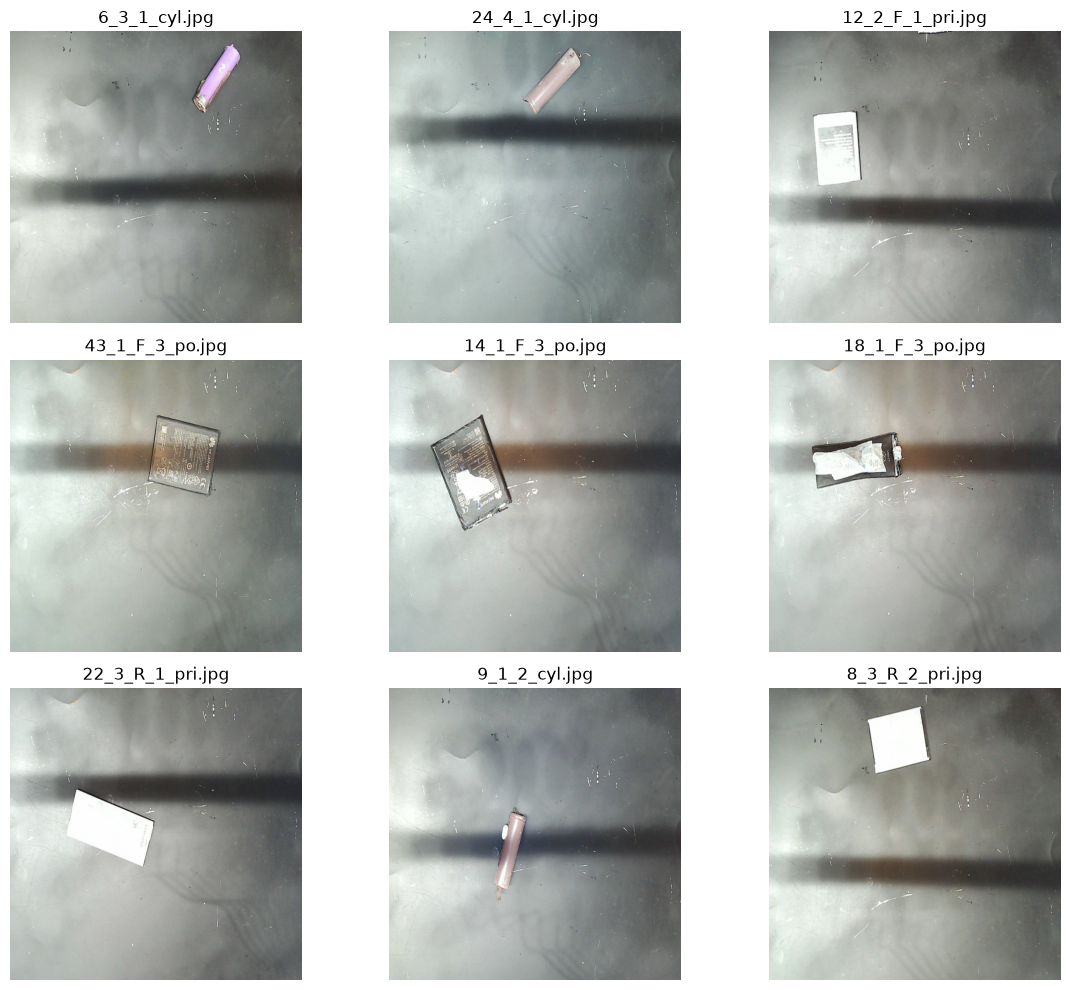

In [5]:
import random
from PIL import Image
import matplotlib.pyplot as plt

images = [
    file for file in dataset_path.rglob("*")
    if file.suffix.lower() in image_extensions
]

sample_images = random.sample(images, 9)

plt.figure(figsize=(12, 10))

for i, image_path in enumerate(sample_images):
    img = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(image_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Check image dimensions

In [6]:
sizes = []

for image_path in images:
    try:
        img = Image.open(image_path)
        sizes.append(img.size)
    except:
        pass

print("Number checked:", len(sizes))

print("First 20 sizes:")
print(sizes[:20])

Number checked: 2828
First 20 sizes:
[(640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640)]


In [7]:
widths = [w for w, h in sizes]
heights = [h for w, h in sizes]

print("Min width:", min(widths))
print("Max width:", max(widths))

print("Min height:", min(heights))
print("Max height:", max(heights))

Min width: 640
Max width: 640
Min height: 640
Max height: 640


Check whether any images are corrupt

In [8]:
corrupt_images = []

for image_path in images:
    try:
        with Image.open(image_path) as img:
            img.verify()
    except Exception:
        corrupt_images.append(image_path)

print("Corrupt images:", len(corrupt_images))

Corrupt images: 0


inspect how the labels are stored

Load annotations.json

In [9]:
import json

annotation_path = dataset_path / "train" / "annotations.json"

with open(annotation_path, "r") as f:
    annotations = json.load(f)

print(type(annotations))
print(annotations.keys())

<class 'dict'>
dict_keys(['images', 'annotations', 'categories'])


See the battery categories

In [10]:
print(annotations["categories"])

[{'id': 0, 'name': 'cylindric'}, {'id': 1, 'name': 'pouch'}, {'id': 2, 'name': 'prismatic'}]


Inspect one image record

In [11]:
print(annotations["images"][0])

{'id': 1, 'width': 640, 'height': 640, 'file_name': '7_5_2_cyl.jpg'}


In [12]:
print(annotations["annotations"][0])

{'id': 0, 'image_id': 1, 'category_id': 0, 'bbox': [424, 73, 130, 108], 'area': 14040, 'iscrowd': 0}


Match an image with its annotation

In [13]:
image_lookup = {
    img["id"]: img
    for img in annotations["images"]
}

category_lookup = {
    cat["id"]: cat["name"]
    for cat in annotations["categories"]
}

print(category_lookup)

{0: 'cylindric', 1: 'pouch', 2: 'prismatic'}


In [14]:
ann = annotations["annotations"][0]

image_info = image_lookup[ann["image_id"]]

print("Image:", image_info["file_name"])
print("Category:", category_lookup[ann["category_id"]])
print("Bounding box:", ann["bbox"])

Image: 7_5_2_cyl.jpg
Category: cylindric
Bounding box: [424, 73, 130, 108]


Actually DRAW the bounding box

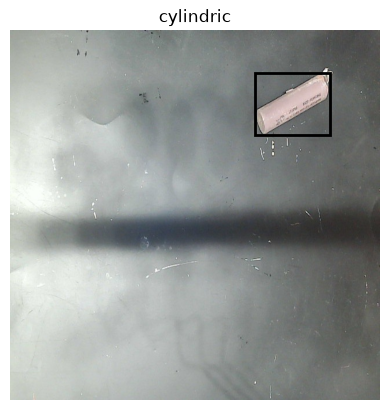

In [15]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

ann = annotations["annotations"][0]

image_info = image_lookup[ann["image_id"]]
image_path = dataset_path / "train" / image_info["file_name"]

img = Image.open(image_path)

x, y, w, h = ann["bbox"]

fig, ax = plt.subplots()

ax.imshow(img)

rectangle = patches.Rectangle(
    (x, y),
    w,
    h,
    fill=False,
    linewidth=2
)

ax.add_patch(rectangle)

ax.set_title(category_lookup[ann["category_id"]])
ax.axis("off")

plt.show()

Check several random bounding boxes

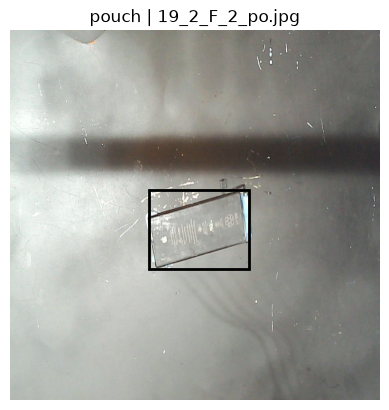

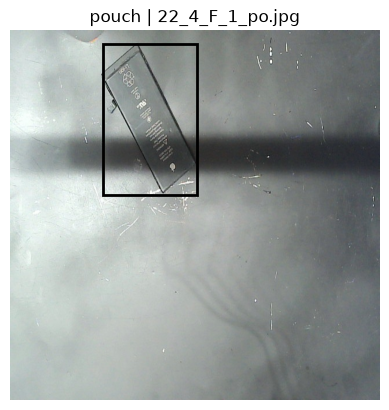

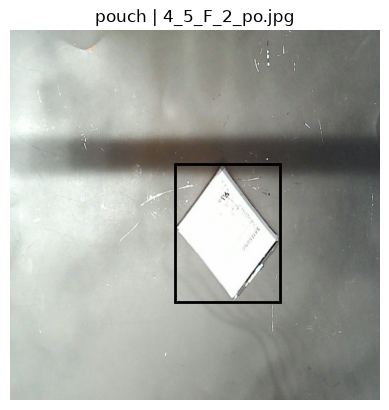

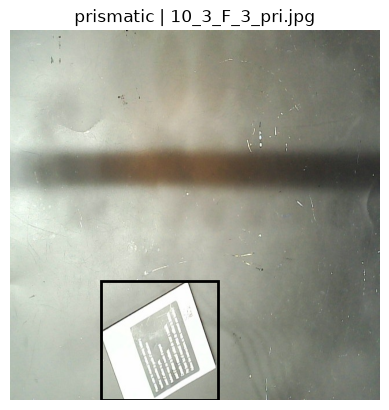

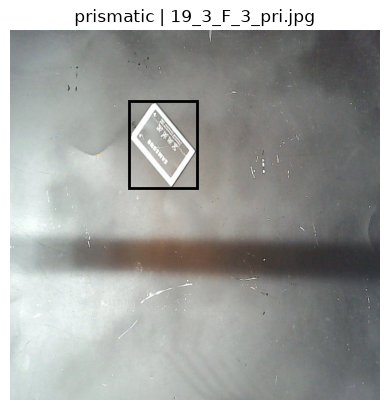

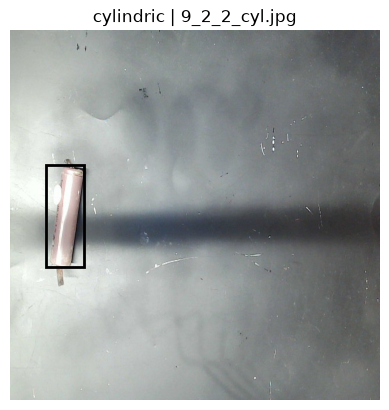

In [16]:
import random

sample_annotations = random.sample(
    annotations["annotations"],
    6
)

for ann in sample_annotations:

    image_info = image_lookup[ann["image_id"]]

    image_path = (
        dataset_path /
        "train" /
        image_info["file_name"]
    )

    img = Image.open(image_path)

    x, y, w, h = ann["bbox"]

    fig, ax = plt.subplots()

    ax.imshow(img)

    rectangle = patches.Rectangle(
        (x, y),
        w,
        h,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rectangle)

    ax.set_title(
        f"{category_lookup[ann['category_id']]} | {image_info['file_name']}"
    )

    ax.axis("off")
    plt.show()

Measure how much of the photograph the battery occupies

In [17]:
bbox_ratios = []

for ann in annotations["annotations"]:

    x, y, w, h = ann["bbox"]

    image_info = image_lookup[ann["image_id"]]

    image_area = image_info["width"] * image_info["height"]
    battery_area = w * h

    ratio = battery_area / image_area

    bbox_ratios.append(ratio)

print("Average battery area ratio:", sum(bbox_ratios) / len(bbox_ratios))
print("Minimum:", min(bbox_ratios))
print("Maximum:", max(bbox_ratios))

Average battery area ratio: 0.07574327653368562
Minimum: 0.013212890625
Maximum: 0.3206396484375


In [19]:
import pandas as pd

rows = []

for split in ["train", "val"]:

    annotation_path = dataset_path / split / "annotations.json"

    with open(annotation_path, "r") as f:
        data = json.load(f)

    image_lookup = {
        img["id"]: img
        for img in data["images"]
    }

    category_lookup = {
        cat["id"]: cat["name"]
        for cat in data["categories"]
    }

    for ann in data["annotations"]:

        image_info = image_lookup[ann["image_id"]]

        x, y, w, h = ann["bbox"]

        image_area = (
            image_info["width"] *
            image_info["height"]
        )

        bbox_area_ratio = (w * h) / image_area

        rows.append({
            "file_name": image_info["file_name"],
            "source_dataset": "RecyBat24",
            "original_split": split,
            "original_label": category_lookup[ann["category_id"]],
            "esafe_label": "battery_powerbank",
            "width": image_info["width"],
            "height": image_info["height"],
            "bbox_x": x,
            "bbox_y": y,
            "bbox_width": w,
            "bbox_height": h,
            "bbox_area_ratio": bbox_area_ratio
        })

df = pd.DataFrame(rows)

df.head()

,file_name,source_dataset,original_split,original_label,esafe_label,width,height,bbox_x,bbox_y,bbox_width,bbox_height,bbox_area_ratio
0,7_5_2_cyl.jpg,RecyBat24,train,cylindric,battery_powerbank,640,640,424,73,130,108,0.034277
1,4_4_1_cyl.jpg,RecyBat24,train,cylindric,battery_powerbank,640,640,403,522,127,59,0.018293
2,2_3_2_cyl.jpg,RecyBat24,train,cylindric,battery_powerbank,640,640,95,303,136,76,0.025234
3,8_5_3_cyl.jpg,RecyBat24,train,cylindric,battery_powerbank,640,640,336,97,86,170,0.035693
4,9_2_1_cyl.jpg,RecyBat24,train,cylindric,battery_powerbank,640,640,168,167,134,82,0.026826


In [20]:
df.insert(
    0,
    "file_id",
    [f"RB{i:05d}" for i in range(1, len(df) + 1)]
)

df.head()

,file_id,file_name,source_dataset,original_split,original_label,esafe_label,width,height,bbox_x,bbox_y,bbox_width,bbox_height,bbox_area_ratio
0,RB00001,7_5_2_cyl.jpg,RecyBat24,train,cylindric,battery_powerbank,640,640,424,73,130,108,0.034277
1,RB00002,4_4_1_cyl.jpg,RecyBat24,train,cylindric,battery_powerbank,640,640,403,522,127,59,0.018293
2,RB00003,2_3_2_cyl.jpg,RecyBat24,train,cylindric,battery_powerbank,640,640,95,303,136,76,0.025234
3,RB00004,8_5_3_cyl.jpg,RecyBat24,train,cylindric,battery_powerbank,640,640,336,97,86,170,0.035693
4,RB00005,9_2_1_cyl.jpg,RecyBat24,train,cylindric,battery_powerbank,640,640,168,167,134,82,0.026826


In [21]:
print(df.shape)
print(df.isnull().sum())

(2871, 13)
file_id            0
file_name          0
source_dataset     0
original_split     0
original_label     0
esafe_label        0
width              0
height             0
bbox_x             0
bbox_y             0
bbox_width         0
bbox_height        0
bbox_area_ratio    0
dtype: int64


In [22]:
df["original_label"].value_counts()

original_label
pouch        1738
prismatic     660
cylindric     473
Name: count, dtype: int64

In [23]:
pd.crosstab(
    df["original_split"],
    df["original_label"]
)

original_label,cylindric,pouch,prismatic
original_split,,,
train,239,868,330
val,234,870,330


In [24]:
output_path = "../../data/metadata/recybat24_manifest.csv"

df.to_csv(output_path, index=False)